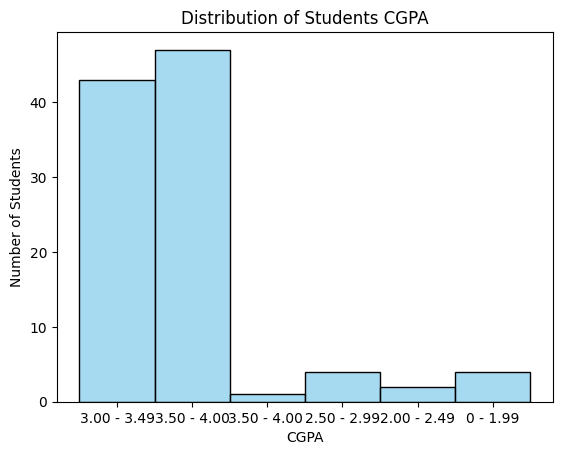

In [4]:
#Exercice:1
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("Student Mental health.csv")


df.head()


sns.histplot(
    data=df,
    x='What is your CGPA?',
    bins=10,
    color='skyblue'
)

plt.title('Distribution of Students CGPA')
plt.xlabel('CGPA')
plt.ylabel('Number of Students')
plt.show()


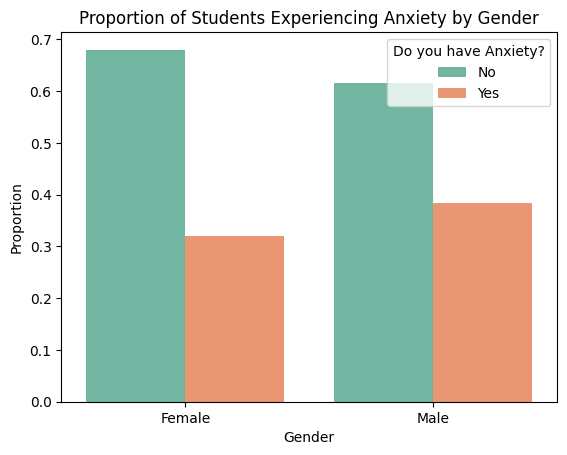

In [ ]:
#Exercice:2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


anxiety_gender = (
    df.groupby('Choose your gender')['Do you have Anxiety?']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)
sns.barplot(
    data=anxiety_gender,
    x='Choose your gender',
    y='Proportion',
    hue='Do you have Anxiety?',
    palette='Set2'
)
plt.title('Proportion of Students Experiencing Anxiety by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.show()


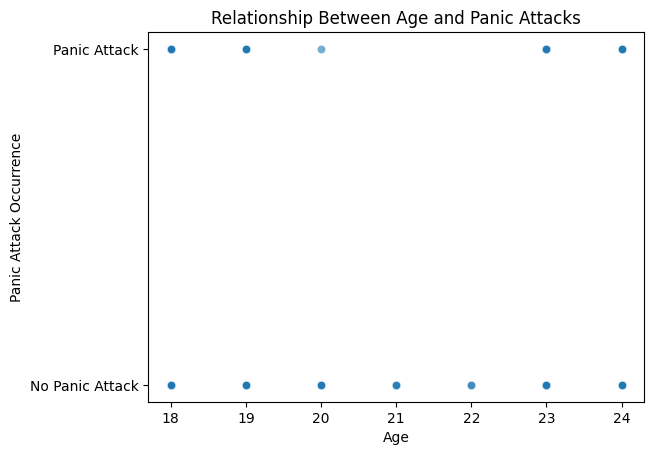

In [ ]:
#Exercice:3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Panic_Attack_Numeric'] = df['Do you have Panic attack?'].map({
    'Yes': 1,
    'No': 0
})

sns.scatterplot(
    data=df,
    x='Age',
    y='Panic_Attack_Numeric',
    alpha=0.6
)
plt.yticks([0, 1], ['No Panic Attack', 'Panic Attack'])
plt.xlabel('Age')
plt.ylabel('Panic Attack Occurrence')
plt.title('Relationship Between Age and Panic Attacks')
plt.show()


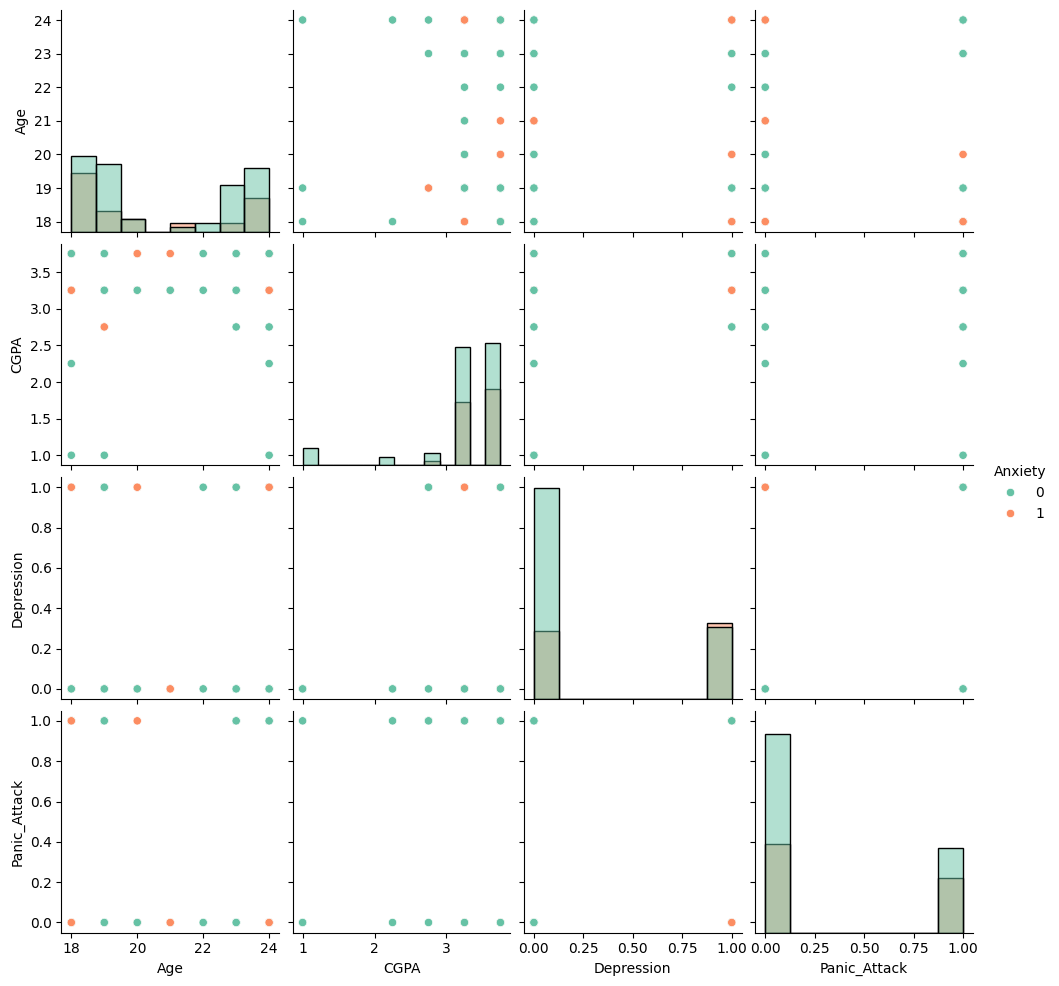

In [ ]:
#Exercice:4
df.rename(columns={
    'What is your CGPA?': 'CGPA',
    'Do you have Depression?': 'Depression',
    'Do you have Anxiety?': 'Anxiety',
    'Do you have Panic attack?': 'Panic_Attack'
}, inplace=True)

df['Depression'] = df['Depression'].map({'Yes': 1, 'No': 0})
df['Anxiety'] = df['Anxiety'].map({'Yes': 1, 'No': 0})
df['Panic_Attack'] = df['Panic_Attack'].map({'Yes': 1, 'No': 0})
cgpa_map = {
    '0 - 1.99': 1.0,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df['CGPA'] = df['CGPA'].map(cgpa_map)
pairplot_df = df[
    ['Age', 'CGPA', 'Depression', 'Anxiety', 'Panic_Attack']
]

sns.pairplot(
    pairplot_df,
    hue='Anxiety',
    diag_kind='hist',
    palette='Set2'
)

plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_19272\3188330095.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[mental_cols] = df[mental_cols].replace({'Yes': 1, 'No': 0})


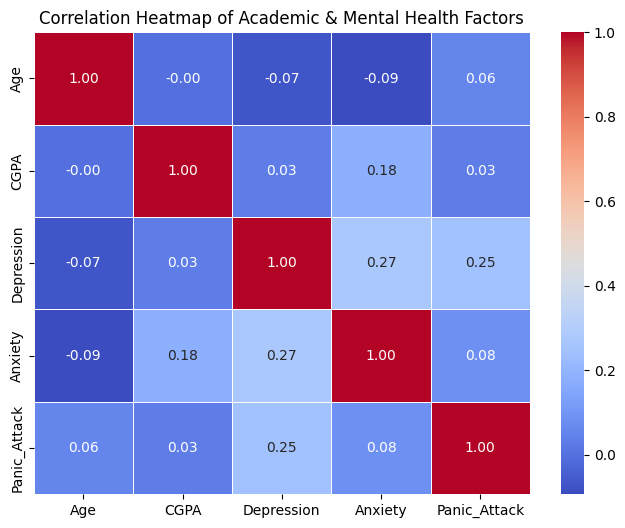

In [ ]:
#Exercice:5
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Student Mental health.csv")

df = df.rename(columns={
    'What is your CGPA?': 'CGPA',
    'Do you have Depression?': 'Depression',
    'Do you have Anxiety?': 'Anxiety',
    'Do you have Panic attack?': 'Panic_Attack'
})


mental_cols = ['Depression', 'Anxiety', 'Panic_Attack']
df[mental_cols] = df[mental_cols].replace({'Yes': 1, 'No': 0})


cgpa_mapping = {
    '0 - 1.99': 1.0,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df['CGPA'] = df['CGPA'].map(cgpa_mapping)

subset = df[['Age', 'CGPA', 'Depression', 'Anxiety', 'Panic_Attack']]


corr_matrix = subset.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Academic & Mental Health Factors")
plt.show()


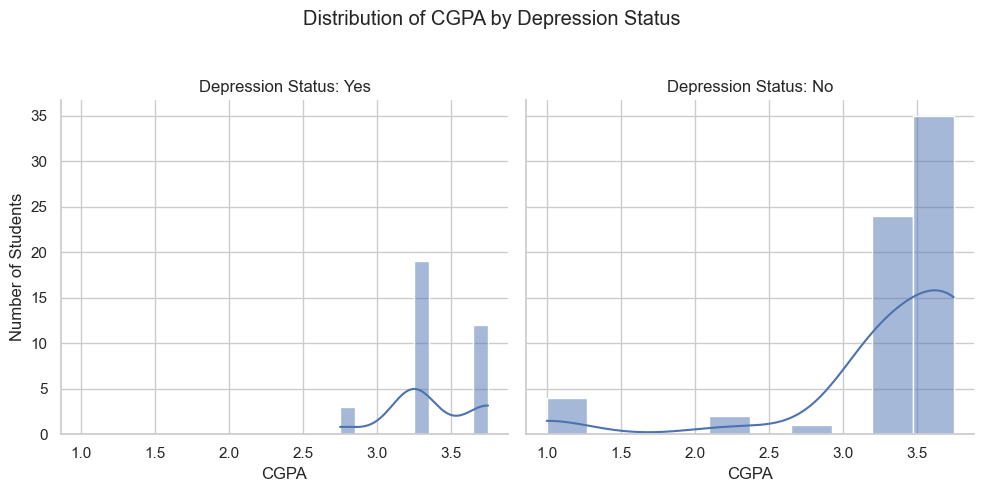

In [11]:
#Exercice:6
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("Student Mental health.csv")

df = df.rename(columns={
    'What is your CGPA?': 'CGPA',
    'Do you have Depression?': 'Depression'
})

cgpa_mapping = {
    '0 - 1.99': 1.0,
    '2.00 - 2.49': 2.25,
    '2.50 - 2.99': 2.75,
    '3.00 - 3.49': 3.25,
    '3.50 - 4.00': 3.75
}

df['CGPA'] = df['CGPA'].map(cgpa_mapping)


sns.set(style="whitegrid")


g = sns.FacetGrid(
    df,
    col="Depression",
    height=5,
    aspect=1
)


g.map(
    sns.histplot,
    "CGPA",
    bins=10,
    kde=True
)


g.set_axis_labels("CGPA", "Number of Students")
g.set_titles("Depression Status: {col_name}")


plt.subplots_adjust(top=0.8)
g.fig.suptitle("Distribution of CGPA by Depression Status")

plt.show()
